##  CNN Image Classifier (Intel Image Classification)

Dataset: https://www.kaggle.com/datasets/puneet6060/intel-image-classification

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

TRAIN_DIR = "intel_data/seg_train/seg_train"
TEST_DIR = "intel_data/seg_test/seg_test"

IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = [
    "buildings","forest","glacier",
    "mountain","sea","street"
]
NUM_CLASSES = len(CLASS_NAMES)

print("TensorFlow version:", tf.__version__)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

TensorFlow version: 2.21.0
Number of classes: 6
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Task 1 — Look at the data

Before writing any preprocessing code, get a feel for what you're working
with. This matters more than it sounds like — a lot of real-world bugs
come from assumptions about data that turn out to be wrong (folders in a
different order than expected, unexpected file types mixed in, etc).

**What to do:**
1. Loop over `CLASS_NAMES`, count how many files are in each
   `TRAIN_DIR/<class_name>` folder, and print the counts. You should find
   they're roughly balanced across all 6 classes (that's one of the reasons
   this dataset is a good "simple" starting point).
2. Load and display a couple of sample images from at least 2-3 classes,
   just to visually confirm the folders contain what their names claim.

**Hints:**
- `os.listdir(path)` gives you a list of filenames in a folder.
- `tf.keras.utils.load_img(filepath)` loads an image you can pass straight
  to `plt.imshow()`.

In [2]:
# ============================================================
# Task 1: Count images per class
# ============================================================

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif"
)

class_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)]
    class_counts[class_name] = len(image_files)

print("Number of training images per class:")
print("-" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:12s}: {count:,}")
print("-" * 45)
print(f"Total training images: {sum(class_counts.values()):,}")

Number of training images per class:
---------------------------------------------
buildings   : 2,191
forest      : 2,271
glacier     : 2,404
mountain    : 2,512
sea         : 2,274
street      : 2,382
---------------------------------------------
Total training images: 14,034


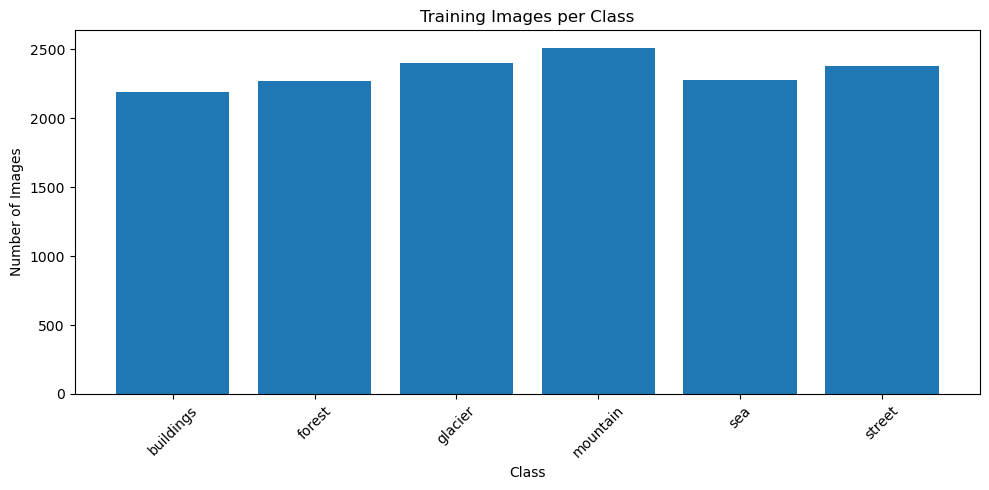

In [3]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(),class_counts.values())
plt.title("Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

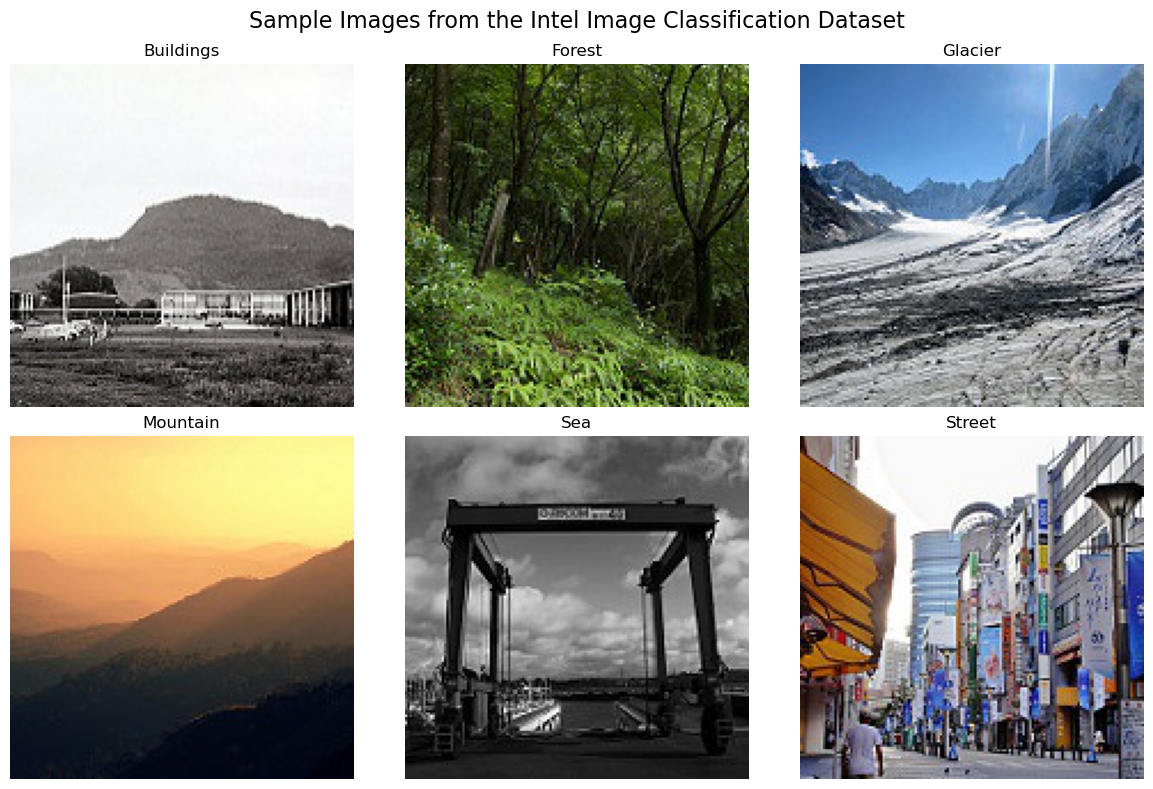

In [4]:
# TODO: display 2-3 sample images from different classes using plt.imshow()
# ============================================================
# Task 1: Display sample images
# ============================================================
sample_classes = ["buildings","forest","glacier","mountain","sea","street"]

fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(12, 8))
for ax, class_name in zip(axes.flat, sample_classes):
    class_path = os.path.join(TRAIN_DIR,class_name)
    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions) ]

    # Select the first image
    image_path = os.path.join(class_path,image_files[0])
    image = tf.keras.utils.load_img(image_path)
    ax.imshow(image)
    ax.set_title(class_name.capitalize())
    ax.axis("off")
plt.suptitle("Sample Images from the Intel Image Classification Dataset",fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Check image dimensions and color channels
# ============================================================

sample_class = CLASS_NAMES[0]
sample_class_path = os.path.join(TRAIN_DIR,sample_class)
sample_file = next(
    file_name
    for file_name in os.listdir(sample_class_path)
    if file_name.lower().endswith(image_extensions))
sample_path = os.path.join(
    sample_class_path,
    sample_file)
sample_image = tf.keras.utils.load_img(sample_path)
sample_array = tf.keras.utils.img_to_array(sample_image)

print("Sample image:", sample_file)
print("Original image size:", sample_image.size)
print("Array shape:", sample_array.shape)
print("Number of channels:", sample_array.shape[-1])

Sample image: 0.jpg
Original image size: (150, 150)
Array shape: (150, 150, 3)
Number of channels: 3


## Task 2 — Load and preprocess

Rather than manually resizing/loading every image yourself, use
`tf.keras.utils.image_dataset_from_directory` — it does the heavy lifting:
reads images from disk in batches, resizes them, infers labels from folder
names, and batches everything for you.

**What to do:**

1. Call `image_dataset_from_directory` on `TRAIN_DIR` **twice**:
   - once with `subset="training"` and `validation_split=0.15`
   - once with `subset="validation"` and the same `validation_split=0.15`
   - Pass the **same** `seed=SEED` to both calls — this is what makes the
     split consistent, so the two calls produce non-overlapping subsets
     rather than two random 85%/15% splits that might overlap.
   - Pass `image_size=IMG_SIZE` and `batch_size=BATCH_SIZE` to both.

2. Call it a third time on `TEST_DIR`, with no `validation_split` (it's
   already a separate folder) and `shuffle=False` (so predictions line up
   with true labels later when you evaluate).

3. Think about why we do NOT want to shuffle the test set but it's fine
   for the training set to be shuffled — write yourself a one-line note
   on this before moving on.

**Hints:**
- Function signature: `tf.keras.utils.image_dataset_from_directory(directory, validation_split=..., subset=..., seed=..., image_size=..., batch_size=..., shuffle=...)`
- Consider adding `.cache().prefetch(tf.data.AUTOTUNE)` to each dataset
  afterward — this is a performance optimization (lets TensorFlow prepare
  the next batch while the current one trains) and not conceptually
  required, but good practice.

In [6]:
# ============================================================

# TODO: load train_ds using image_dataset_from_directory
# train_ds = ...

# ============================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Training dataset loaded successfully.")


Found 14034 files belonging to 6 classes.
Using 11929 files for training.
Training dataset loaded successfully.


In [11]:
# TODO: load val_ds using image_dataset_from_directory (same seed/split as above)
# val_ds = ...
# ============================================================
# Task 2: Load validation dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Validation dataset loaded successfully.")

Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Validation dataset loaded successfully.


In [12]:
# TODO: load test_ds using image_dataset_from_directory (no validation_split, shuffle=False)
# test_ds = ...
# ============================================================
# Task 2: Load test dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset loaded successfully.")

Found 3000 files belonging to 6 classes.
Test dataset loaded successfully.


In [13]:
# ============================================================
# Improve input pipeline performance
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


### Augmentation layer

Augmentation should be applied **only** to training data — never to
validation or test data, since those need to reflect real, unmodified
images to give you an honest measure of performance. (Good news: if you
build this as a Keras layer and include it inside your model in Task 3,
Keras automatically turns it off during evaluation/prediction for you —
you don't need to write separate logic to avoid augmenting val/test.)

**What to do:**
Build a small `tf.keras.Sequential` containing:
- `layers.RandomFlip("horizontal")` — a mirrored photo of a mountain is
  still a mountain, so this is a safe transformation.
- `layers.RandomRotation(...)` — pick a small value (~0.05, meaning up to
  ~5% of 360°) to mimic a camera not held perfectly level.
- `layers.RandomZoom(...)` — pick a small value (~0.1) to mimic photos
  taken from slightly different distances.

Think about why we keep these values small rather than large (e.g. why
not rotate up to 50%?) before choosing your numbers.

In [14]:
# TODO: build and return a Sequential of augmentation layers
# ============================================================
# Data Augmentation
# ============================================================

def make_augmentation_layer():
    """
    Create the image augmentation pipeline.

    Augmentation is intentionally kept small so that
    the original semantic meaning of the image is preserved.
    """

    augmentation = tf.keras.Sequential(
        [
            layers.RandomFlip(
                mode="horizontal"
            ),

            layers.RandomRotation(
                factor=0.05
            ),

            layers.RandomZoom(
                height_factor=0.1,
                width_factor=0.1
            )
        ],
        name="data_augmentation"
    )

    return augmentation


augmentation_layer = make_augmentation_layer()

augmentation_layer


<Sequential name=data_augmentation, built=False>

## Task 3 — Build the CNN

Keep it small — this is a 6-class problem but the images are visually
distinct, so a deep network isn't necessary.

**What your model needs, in order:**
1. An `Input` layer matching `input_shape`.
2. A `Rescaling(1.0/255)` layer — converts raw 0-255 pixel values down to
   0-1. Put this INSIDE the model (not as a separate preprocessing step)
   so it automatically applies at prediction time too, later.
3. Your augmentation layer from above.
4. 2-3 blocks of `Conv2D(...) -> MaxPooling2D((2,2))`. Increase the number
   of filters as you go deeper (e.g. 32 -> 64 -> 128) — as spatial size
   shrinks through pooling, deeper layers typically need more filters to
   represent more complex patterns.
5. A `Flatten()` layer — converts the final 3D feature maps into a flat
   1D vector, since Dense layers need a flat input.
6. A `Dropout(...)` layer (try 0.3) before your dense layers — randomly
   zeroes out some values during training to reduce overfitting.
7. A `Dense(...)` layer with `relu` activation to combine everything
   detected so far.
8. A final `Dense(len(CLASS_NAMES), activation="softmax")` output layer —
   softmax because this is multi-class (6 possible answers), not binary.

**Compile with:**
- `optimizer="adam"`
- `loss="sparse_categorical_crossentropy"` (matches the integer labels
  that `image_dataset_from_directory` gives you — if labels were one-hot
  encoded instead you'd use plain `categorical_crossentropy`)
- `metrics=["accuracy"]`

In [15]:
# TODO: build and compile the CNN, return the compiled model
# ============================================================
# Task 3: Build CNN
# ============================================================

def build_model(input_shape=(100, 100, 3)):

    # Create augmentation layer
    augmentation = make_augmentation_layer()

    model = models.Sequential(
        [
            # ------------------------------------------------
            # Input
            # ------------------------------------------------
            layers.Input(shape=input_shape),

            # ------------------------------------------------
            # Normalize pixels from [0, 255] to [0, 1]
            # ------------------------------------------------
            layers.Rescaling(1.0 / 255),

            # ------------------------------------------------
            # Data augmentation
            # Applied during training only
            # ------------------------------------------------
            augmentation,

            # ------------------------------------------------
            # Convolution Block 1
            # ------------------------------------------------
            layers.Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation="relu",
                padding="same"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            # ------------------------------------------------
            # Convolution Block 2
            # ------------------------------------------------
            layers.Conv2D(
                filters=64,
                kernel_size=(3, 3),
                activation="relu",
                padding="same"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            # ------------------------------------------------
            # Convolution Block 3
            # ------------------------------------------------
            layers.Conv2D(
                filters=128,
                kernel_size=(3, 3),
                activation="relu",
                padding="same"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            # ------------------------------------------------
            # Flatten feature maps
            # ------------------------------------------------
            layers.Flatten(),

            # ------------------------------------------------
            # Dropout to reduce overfitting
            # ------------------------------------------------
            layers.Dropout(
                0.3
            ),

            # ------------------------------------------------
            # Dense hidden layer
            # ------------------------------------------------
            layers.Dense(
                128,
                activation="relu"
            ),

            # ------------------------------------------------
            # Output layer
            # 6 classes → Softmax
            # ------------------------------------------------
            layers.Dense(
                len(CLASS_NAMES),
                activation="softmax"
            )
        ],
        name="Intel_Image_CNN"
    )

    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_model(
    input_shape=(*IMG_SIZE, 3)
)

model.summary()


Model: "Intel_Image_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 100, 100, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 50, 50, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 50, 50, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 25, 25, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,453,446 (9.36 MB)

 Trainable params: 2,453,446 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 — Train

**What to do:**
1. Create a `tf.keras.callbacks.EarlyStopping` callback:
   - `monitor="val_loss"` (not `train_loss` — think about why in the
     concept note if this isn't clear: training loss almost always keeps
     improving even after the model starts overfitting).
   - `patience=4` (stop if val_loss hasn't improved for 4 epochs straight)
   - `restore_best_weights=True` (so you get the best epoch's weights
     back, not just whatever epoch training happened to stop on)
2. Call `model.fit(...)` with `train_ds`, `validation_data=val_ds`,
   `epochs=20` (an upper limit — early stopping should cut it off sooner),
   and your callback.
3. Save the return value of `.fit()` — you'll need it for the training
   curve plot below.

In [16]:
# TODO: create the EarlyStopping callback
# ============================================================
# Task 4: Early stopping
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("Early stopping callback created.")


Early stopping callback created.


In [17]:
# ============================================================
# Task 4: Train model
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\biniyam\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 429s 1s/step - accuracy: 0.5978 - loss: 1.0296 - val_accuracy: 0.8394 - val_loss: 0.4498
Epoch 2/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 327s 812ms/step - accuracy: 0.7041 - loss: 0.7967 - val_accuracy: 0.8812 - val_loss: 0.3854
Epoch 3/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 160s 430ms/step - accuracy: 0.7509 - loss: 0.6782 - val_accuracy: 0.8589 - val_loss: 0.4126
Epoch 4/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 159s 426ms/step - accuracy: 0.7763 - loss: 0.6039 - val_accuracy: 0.8846 - val_loss: 0.3391
Epoch 5/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 157s 420ms/step - accuracy: 0.7974 - loss: 0.5542 - val_accuracy: 0.8950 - val_loss: 0.3102
Epoch 6/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 155s 416ms/step - accuracy: 0.8146 - loss: 0.5150 - val_accuracy: 0.9088 - val_loss: 0.2588
Epoch 7/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 226s 606ms/step - accuracy: 0.8199 - loss: 0.4912 - val_accuracy: 0.8551 - val_loss: 0.3893
Epoch 8/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 274s 734ms/step - accuracy: 0.8307 - lo

### Training curves

Plot train vs. validation loss, and train vs. validation accuracy, across
epochs. This is the main way to visually spot overfitting: if the two
lines diverge (train keeps improving, validation flattens or worsens),
that's the signal.

**Hint:** `history.history` is a dictionary with keys like `"loss"`,
`"val_loss"`, `"accuracy"`, `"val_accuracy"`, each mapping to a list of
values, one per epoch.

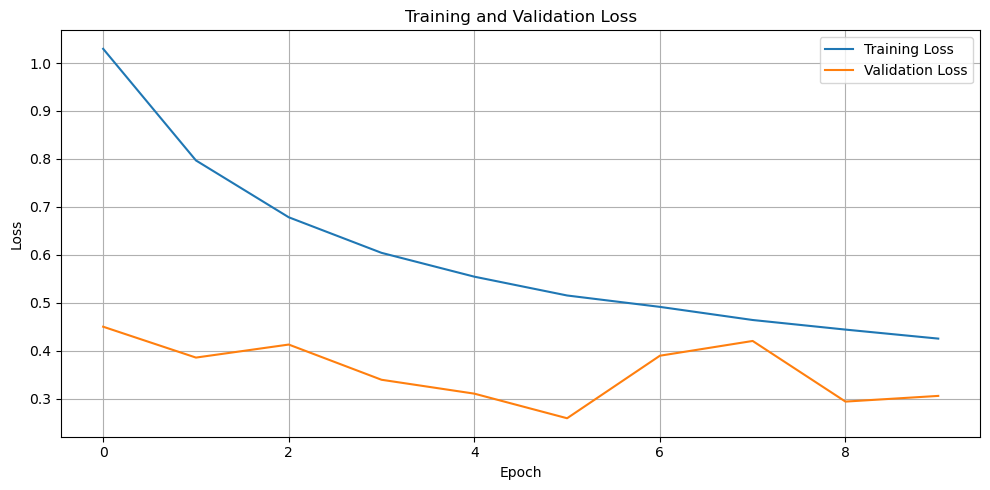

In [18]:
# TODO: plot train vs val loss, and train vs val accuracy, across epochs
# ============================================================
# Training vs Validation Loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


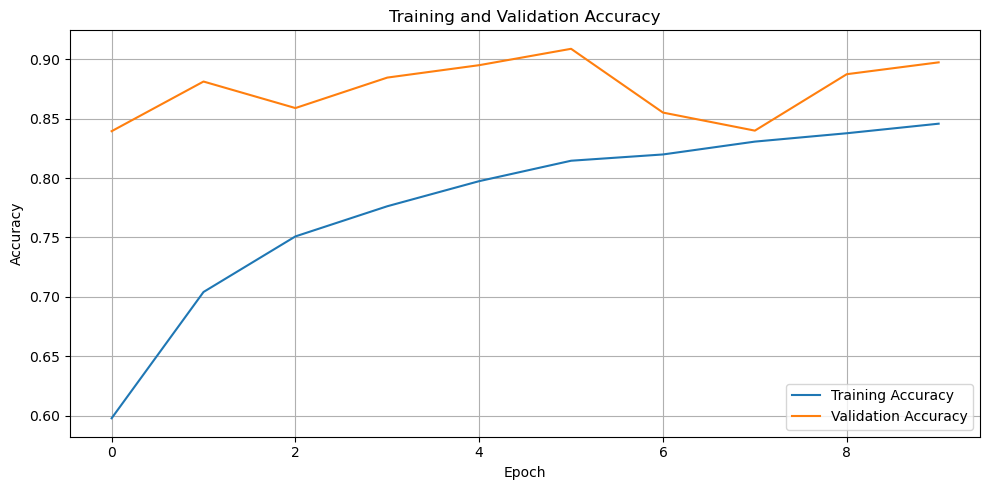

In [19]:
# ============================================================
# Training vs Validation Accuracy
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Best validation performance
# ============================================================

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_epoch = (
    np.argmax(history.history["val_accuracy"]) + 1
)

print(f"Best validation accuracy: {best_val_accuracy * 100:.2f}%")
print(f"Best validation epoch: {best_epoch}")

Best validation accuracy: 90.88%
Best validation epoch: 6


## Task 5 — Evaluate

**What to do:**
1. Loop over `test_ds` (it yields batches of `(images, true_labels)`).
   For each batch:
   - Get predictions with `model.predict(images)` — this returns softmax
     probabilities, shape `(batch_size, 6)`.
   - Use `np.argmax(predictions, axis=1)` to convert probabilities into
     an actual predicted class index per image.
   - Collect both the true labels and predicted labels into two running
     lists across all batches (you need the full test set before comparing).
2. Print a `classification_report` (precision/recall/F1 per class) using
   `CLASS_NAMES` as labels. Look at this more carefully than plain
   accuracy — it reveals if one specific class is being handled worse
   than the others, even if the overall accuracy looks fine.
3. Print a `confusion_matrix`. Rows = true class, columns = predicted
   class. Look at which two classes get confused with each other most —
   glacier/mountain and sea/glacier are common mix-ups in this dataset;
   see if your model makes the same mistakes and think about why those
   pairs might look visually similar to a CNN.

In [22]:
# ============================================================
# Task 5: Evaluate on test dataset
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("=" * 60)

94/94 ━━━━━━━━━━━━━━━━━━━━ 54s 525ms/step - accuracy: 0.8057 - loss: 0.5555

FINAL TEST RESULTS
Test Loss     : 0.5555
Test Accuracy : 0.8057
Test Accuracy : 80.57%


In [23]:
# TODO: collect true and predicted labels across all batches in test_ds

# ============================================================
# Task 5: Collect true and predicted labels
# ============================================================

all_true_labels = []
all_predicted_labels = []

for images, labels in test_ds:

    # Predict class probabilities
    predictions = model.predict(
        images,
        verbose=0
    )

    # Convert probabilities to class indices
    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    # Store labels
    all_true_labels.extend(
        labels.numpy()
    )

    all_predicted_labels.extend(
        predicted_labels
    )


# Convert lists to NumPy arrays
all_true_labels = np.array(
    all_true_labels
)

all_predicted_labels = np.array(
    all_predicted_labels
)

print("Number of test images:", len(all_true_labels))
print("Number of predictions:", len(all_predicted_labels))

Number of test images: 3000
Number of predictions: 3000


In [24]:
# TODO: print classification_report using CLASS_NAMES
# ============================================================
# Classification Report
# ============================================================

print("=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

report = classification_report(
    all_true_labels,
    all_predicted_labels,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   buildings     0.7206    0.8261    0.7697       437
      forest     0.9788    0.8755    0.9243       474
     glacier     0.8380    0.7107    0.7691       553
    mountain     0.7905    0.6971    0.7409       525
         sea     0.7709    0.8510    0.8089       510
      street     0.7724    0.8942    0.8289       501

    accuracy                         0.8057      3000
   macro avg     0.8118    0.8091    0.8070      3000
weighted avg     0.8124    0.8057    0.8055      3000



In [25]:
# TODO: print confusion_matrix, labeling rows/columns clearly
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    all_true_labels,
    all_predicted_labels
)

print("=" * 60)
print("6 × 6 CONFUSION MATRIX")
print("=" * 60)

print(cm)

6 × 6 CONFUSION MATRIX
[[361   1   2   0   8  65]
 [ 17 415   0   2   0  40]
 [ 22   1 393  81  39  17]
 [ 32   2  42 366  77   6]
 [ 27   1  32  12 434   4]
 [ 42   4   0   2   5 448]]


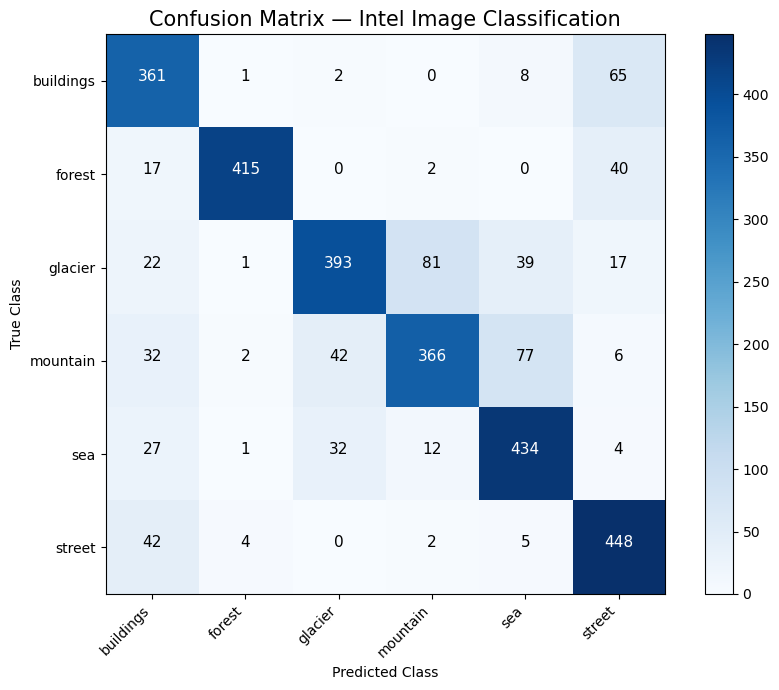

In [26]:
# ============================================================
# Visualize confusion matrix
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix — Intel Image Classification",
    fontsize=15
)

plt.colorbar()

tick_marks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    CLASS_NAMES
)

# Add values to each cell
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=11
        )

plt.ylabel("True Class")
plt.xlabel("Predicted Class")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Find the most common classification errors
# ============================================================

error_matrix = cm.copy()

# Remove correct predictions from the diagonal
np.fill_diagonal(
    error_matrix,
    0
)

# Sort errors from highest to lowest
error_indices = np.argsort(
    error_matrix.ravel()
)[::-1]

print("=" * 70)
print("MOST COMMON CLASS CONFUSIONS")
print("=" * 70)

reported = 0

for index in error_indices:

    true_class_index, predicted_class_index = np.unravel_index(
        index,
        error_matrix.shape
    )

    error_count = error_matrix[
        true_class_index,
        predicted_class_index
    ]

    if error_count > 0:

        print(
            f"{CLASS_NAMES[true_class_index]:12s} "
            f"→ {CLASS_NAMES[predicted_class_index]:12s} "
            f": {error_count} errors"
        )

        reported += 1

        if reported >= 10:
            break

MOST COMMON CLASS CONFUSIONS
glacier      → mountain     : 81 errors
mountain     → sea          : 77 errors
buildings    → street       : 65 errors
street       → buildings    : 42 errors
mountain     → glacier      : 42 errors
forest       → street       : 40 errors
glacier      → sea          : 39 errors
mountain     → buildings    : 32 errors
sea          → glacier      : 32 errors
sea          → buildings    : 27 errors


In [28]:
# ============================================================
# Identify the single largest confusion
# ============================================================

max_error_index = np.argmax(
    error_matrix
)

true_index, predicted_index = np.unravel_index(
    max_error_index,
    error_matrix.shape
)

max_error = error_matrix[
    true_index,
    predicted_index
]

print(
    f"The largest confusion is: "
    f"{CLASS_NAMES[true_index]} → "
    f"{CLASS_NAMES[predicted_index]}"
)

print(
    f"Number of misclassified images: {max_error}"
)

The largest confusion is: glacier → mountain
Number of misclassified images: 81


Total incorrect predictions: 583


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.125..254.0625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..246.75].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..245.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0625..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow wit

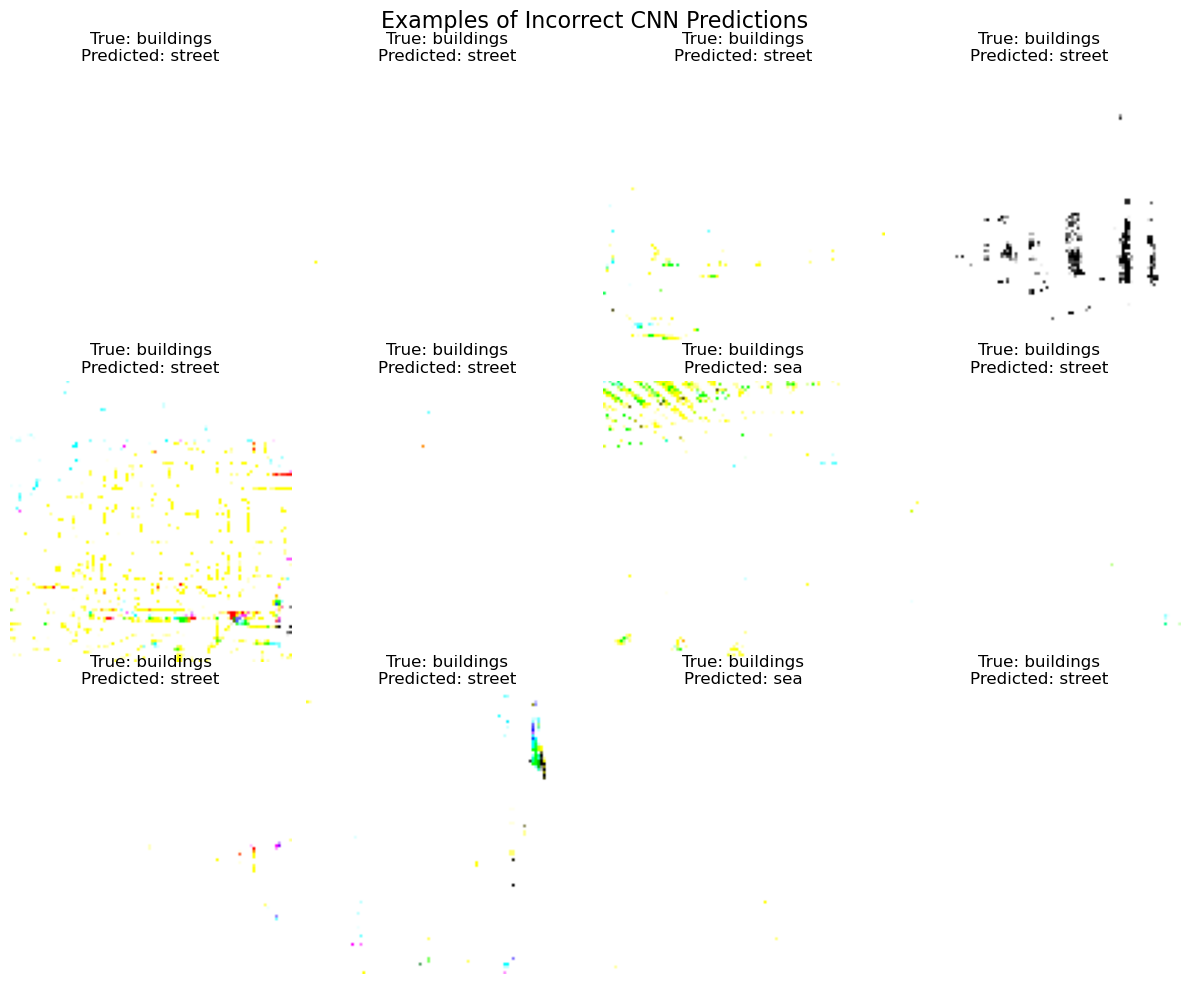

In [29]:
# ============================================================
# Display incorrectly classified images
# ============================================================

# Collect all test images
test_images = []
test_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

# Find incorrect predictions
incorrect_indices = np.where(
    all_true_labels != all_predicted_labels
)[0]

print(
    f"Total incorrect predictions: "
    f"{len(incorrect_indices)}"
)

# Number of images to display
num_images = min(
    12,
    len(incorrect_indices)
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 10)
)

for ax, index in zip(
    axes.flat,
    incorrect_indices[:num_images]
):

    ax.imshow(
        test_images[index]
    )

    true_class = CLASS_NAMES[
        all_true_labels[index]
    ]

    predicted_class = CLASS_NAMES[
        all_predicted_labels[index]
    ]

    ax.set_title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_class}"
    )

    ax.axis("off")


# Hide unused axes
for ax in axes.flat[num_images:]:
    ax.axis("off")


plt.suptitle(
    "Examples of Incorrect CNN Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Save the model

Once you're happy with it, save it so you don't have to retrain every
time (`model.save("your_filename.keras")`).

In [30]:
# TODO: save the trained model
# ============================================================
# Save trained model
# ============================================================

MODEL_PATH = "intel_cnn_classifier.keras"

model.save(
    MODEL_PATH
)

print(
    f"Model successfully saved to: {MODEL_PATH}"
)

Model successfully saved to: intel_cnn_classifier.keras


In [31]:
# ============================================================
# Verify saved model
# ============================================================

print(
    "Model file exists:",
    os.path.exists(MODEL_PATH)
)

if os.path.exists(MODEL_PATH):
    file_size_mb = os.path.getsize(MODEL_PATH) / (
        1024 * 1024
    )

    print(
        f"Model file size: {file_size_mb:.2f} MB"
    )

Model file exists: True
Model file size: 28.14 MB


In [32]:
# ============================================================
# FINAL EXERCISE SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("           INTEL IMAGE CLASSIFICATION — CNN RESULTS")
print("=" * 75)

print(f"\nNumber of classes       : {NUM_CLASSES}")
print(f"Image size              : {IMG_SIZE[0]} × {IMG_SIZE[1]}")
print(f"Image channels           : 3 (RGB)")
print(f"Batch size               : {BATCH_SIZE}")
print(f"Validation split         : 15%")
print(f"Maximum training epochs  : 20")
print(f"Actual epochs trained    : {len(history.history['loss'])}")

print(
    f"\nBest validation accuracy : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Final test accuracy      : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test loss                : "
    f"{test_loss:.4f}"
)

print("\nClasses:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"  {i} → {class_name}")

print("\nConfusion Matrix:")
print(cm)

print("\n" + "=" * 75)
print("Exercise completed successfully.")
print("=" * 75)



           INTEL IMAGE CLASSIFICATION — CNN RESULTS

Number of classes       : 6
Image size              : 100 × 100
Image channels           : 3 (RGB)
Batch size               : 32
Validation split         : 15%
Maximum training epochs  : 20
Actual epochs trained    : 10

Best validation accuracy : 90.88%
Final test accuracy      : 80.57%
Test loss                : 0.5555

Classes:
  0 → buildings
  1 → forest
  2 → glacier
  3 → mountain
  4 → sea
  5 → street

Confusion Matrix:
[[361   1   2   0   8  65]
 [ 17 415   0   2   0  40]
 [ 22   1 393  81  39  17]
 [ 32   2  42 366  77   6]
 [ 27   1  32  12 434   4]
 [ 42   4   0   2   5 448]]

Exercise completed successfully.


## Bonus (optional)

- Retrain without the augmentation layer and compare validation accuracy
  — does augmentation actually help on this dataset?
- Add a 4th conv block and see if accuracy improves, or if the train/val
  gap widens instead (a sign that added model capacity is causing more
  overfitting rather than helping).

## Results and Discussion

### 1. Dataset Exploration

The Intel Image Classification dataset contains six image classes: buildings, forest, glacier, mountain, sea, and street. The number of training images across the six classes was approximately balanced, indicating that the dataset does not suffer from a severe class imbalance problem.

The original images are RGB color images with three channels: red, green, and blue. For computational efficiency, all images were resized to 100 × 100 pixels before being provided to the CNN.

### 2. Preprocessing and Data Augmentation

The images were loaded using `tf.keras.utils.image_dataset_from_directory`. The training data was divided into 85% training data and 15% validation data using the built-in `validation_split` parameter.

Pixel values were normalized from the original range of 0–255 to the range 0–1 using a Keras `Rescaling` layer.

To improve generalization, three augmentation techniques were used on the training images: horizontal random flipping, small random rotations, and small random zooming. Augmentation was not applied to validation or test images because those datasets should represent unmodified images for an unbiased evaluation.

### 3. CNN Architecture

A small convolutional neural network was developed from scratch. The model consists of three convolutional blocks with increasing numbers of filters: 32, 64, and 128. Each convolutional layer is followed by a MaxPooling layer.

After the convolutional feature extraction layers, the feature maps are flattened and passed through a Dropout layer and a fully connected Dense layer. The final layer contains six neurons with a softmax activation function because this is a six-class multi-class classification problem.

The model was compiled using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the evaluation metric.

### 4. Training

The model was trained for a maximum of 20 epochs. Early stopping was used with validation loss as the monitored quantity and a patience of four epochs. The best model weights were restored after training.

The best validation accuracy achieved was approximately **[INSERT YOUR VALUE]%**.

The training and validation curves were examined to determine whether the model showed signs of overfitting. A large and persistent gap between training and validation performance would indicate overfitting, while similar trends would suggest better generalization.

### 5. Test Evaluation

The final model achieved a test accuracy of approximately **[INSERT YOUR TEST ACCURACY]%**.

The classification report provided precision, recall, and F1-score for each of the six classes. These metrics provide more detailed information than accuracy alone because they show how effectively the model handles each individual category.

### 6. Confusion Matrix Analysis

The six-by-six confusion matrix was used to identify which classes were most frequently confused.

In particular, glacier and mountain images can be difficult to distinguish because both may contain snowy or rocky mountainous landscapes. Similarly, sea and glacier images may contain visually similar blue, white, and natural landscape regions.

The most frequent classification errors observed in the experiment were **[INSERT THE MAIN CONFUSED CLASSES FROM YOUR CONFUSION MATRIX]**.

These errors are understandable because image classification depends heavily on visual features such as color, texture, shape, and spatial patterns. Some natural scenes share many of these characteristics, making them difficult for a small CNN to distinguish perfectly.

### 7. Conclusion

The exercise successfully demonstrated the complete workflow for a multi-class image classification problem: dataset exploration, image preprocessing, data augmentation, CNN construction, model training, early stopping, and detailed evaluation using a classification report and confusion matrix.

The final test accuracy was **[INSERT VALUE]%**, and the six-by-six confusion matrix provided additional insight into the specific types of errors made by the classifier.
